# <span style="color:blue;font-weight:bold;font-size:1.1em">Day 8: Understanding Descriptive Statistics</span>

### <span style="font-weight:bold;font-size:1.1em">With additional material: Histograms and Line Plots</span>

In this notebook we will cover:
- How statistics like the **average** and **median** are calculated and what the <span style="font-weight:bold;color:red;font-size:1.1em">mean</span>.
- Additional details on **histograms** and bin width.
- How to use **line plots** with time series data.

In [1]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import scipy.stats as stats
from scipy.stats import gaussian_kde

## Read in a CSV data file from the web.
sky = Table.read_table('skyscrapers.csv')
top_movies = Table.read_table('top_movies_2017.csv')
pers = Table.read_table('http://faculty.ung.edu/rsinn/personality.csv')
births = Table.read_table('https://faculty.ung.edu/rsinn/data/baby.csv')
survey = Table.read_table('welcome_survey_v1.csv')

In [2]:
def describe(data, var = None):
  if isinstance(data, Table):
    data = data.column(var)
  names = np.array(["mean", "std", "n", " : : ", "min", "Q1", "median", "Q3", "max", "IQR"])
  values = np.array([round(np.mean(data),1), round(stats.tstd(data),2), len(data) - 1, "", min(data), np.percentile(data, 25), np.median(data), np.percentile(data, 75), max(data), stats.iqr(data)])
  tab = Table().with_columns('Names', names, 'Values', values)  ;  transposed_tab = Table().with_columns( zip(tab.column('Names'), tab.column('Values')) ).show()
  return

def describes(data, num, group):
  dat = data.column(num)  ;  group_var = data.column(group)  ;  groups = np.unique(group_var)  ;  rows = []  ;  tab = Table(["mean", "std", "n", " : : ", "min", "Q1", "median", "Q3", "max", "IQR"])
  for g in groups:
    # Filter data for the current group
    sub_dat = dat[group_var == g]  ;    rows = [g, round(np.mean(sub_dat), 1), round(stats.tstd(sub_dat), 2), len(sub_dat) - 1, min(sub_dat), np.percentile(sub_dat, 25), np.median(sub_dat), np.percentile(sub_dat, 75), max(sub_dat), stats.iqr(sub_dat)]        
    tab = tab.with_row(rows)
  tab.show()
  return

def box(data, num = None, sm = False):
  if isinstance(data, Table):
    df = data.to_df()  ;  sns.boxplot(data=df, y=num, width=0.45, showmeans=sm)  ;
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()  
  else:
    if num == True:
      sm = True  ;  num = 'Variable'
    if num == None:
      num = 'Variable'
    plots.figure(figsize=(6, 6))  ;  plots.boxplot(data, widths = 0.45, showmeans=sm)
    plots.title(f'Boxplot of {num}')  ;  plots.xticks([], [])  ;  plots.show()
  return

def boxes(data, num, cat, sm = False):
  if not isinstance(data, Table):
    print("ERROR: First input must be table name.")
  else:
    df = data.to_df()  ;  sns.boxplot(data=data, x=cat, y=num, width=0.75, showmeans=sm)
    plots.title(f'Boxplot of {num} Grouped by {cat}')  ;  plots.show()
  return

## <span style="color:blue;font-weight:bold;font-size:1.1em">1. The Mean</span>

The mean is often denoted by $\overline{x}$.

$$\overline{x} = \frac{x_1+x_2+x_3+ \cdots +x_n}{n} = \frac{1}{n} \sum_{i=1}^n x_i$$

For an array like $Height$, we use $\overline{x}$ to refer to the average height.



**The mean of a dataset can be visualized as the balancing point; see the gif below.**

![Mean](Mean2.gif)

To find a mean `np.mean` and `np.average` will both work, as long as your data exists as a single array.  

### <span style="font-weight:bold;font-size:1.1em">Practice Question: for the data given, find the mean with both <span style="color:red">np.mean</span> and <span style="color:red">np.average</span></span> 


In [3]:
# Sleep Hours from Personality Data Set
sleep = pers.column('Sleep')
sleep[:10]

array([  3.5,   5.5,   8.5,   7. ,   6. ,   6.5,   6. ,  10. ,   3. ,   3. ])

In [4]:
avg = ...

In [5]:
mean = ...

## <span style="color:blue;font-weight:bold;font-size:1.1em">2. Box Plots</span>

Five Number Summary is as follows

- The minimum
- The $25^{th}$ percentile, $Q_1$
- The $50^{th}$ percentile, the median
- The $75^{th}$ percentile, $Q_3$
- The maximum

The graphic below shows a box plot that is labeled to show the important relationships within it.

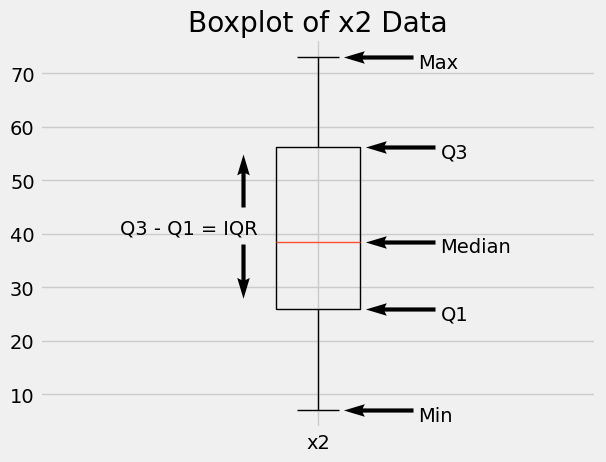

In [6]:
x = make_array(43, 20, 51, 7, 28, 34, 72)  ;  x2 = make_array(43, 20, 51, 7, 28, 34, 72, 73)
plots.boxplot(x2)  ;  plots.title("Boxplot of x2 Data")  ;  plots.xticks(make_array(1), make_array("x2"))
plots.quiver(1.17,73, -1,0, scale=8)  ;  plots.text(1.18, 71,"Max")  ;  plots.quiver(1.17,7, -1,0, scale=8)  ;  plots.text(1.18, 5,"Min")
plots.quiver(1.21,38.5, -1,0, scale=8)  ;  plots.text(1.22,36.5,"Median")  ;  plots.quiver(1.21,56.25, -1,0, scale=8)  ;  plots.text(1.22,54.25,"Q3")
plots.quiver(1.21,26, -1,0, scale=8)  ;  plots.text(1.22,24,"Q1")
plots.text(.645, 40, "Q3 - Q1 = IQR")  ;  plots.quiver(.865,45, 0,1, scale=10.5)  ;  plots.quiver(.865,38, 0,-1, scale=10.25)

### <span style="color:blue;font-weight:bold;font-size:1.1em">Box Plots Pair Well with the describe() and describes() Functions</span>

The first example below shows the **one numerical variable** scenario.

In [7]:
describe(sleep, 'Sleep')

mean,std,n,: :,min,Q1,median,Q3,max,IQR
6.2,2.13,128,,0.5,5.0,6.5,7.5,11.0,2.5


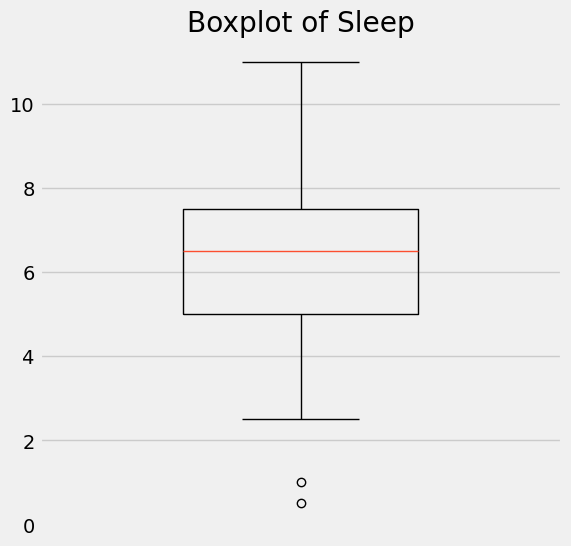

In [8]:
box(sleep, 'Sleep')

### <span style="color:blue;font-weight:bold;font-size:1.1em">A Much Larger Data Set</span>

Let's do all this again with a data set showing salary data from San Francisco city employees in 2015. The **sf** table has tens of thousands of rows.

In [9]:
sf = Table.read_table('san_francisco_2015.csv')
min_salary = 10 * 20 * 52
sf = sf.where('Total Compensation', are.above(min_salary))

describes(sf, 'Total Compensation', 'Organization Group')

/opt/conda/lib/python3.11/site-packages/scipy/stats/_stats_py.py:667: RuntimeWarning: Degrees of freedom <= 0 for slice.
  return np.nanvar(a, ddof=ddof, axis=axis)


mean,std,n,: :,min,Q1,median,Q3,max,IQR
Community Health,107225,63171.3,8310,10409.8,63365.4,97587.8,142281,422800,78915.6
Culture & Recreation,72898.3,47448.9,2600,10403.1,25771.1,75930.4,106002,315370,80230.6
General Administration & Finance,106667,64870.3,3376,10412.9,54387.7,103675,144388,648875,90000.2
General City Responsibilities,10536.9,nan,0,10536.9,10536.9,10536.9,10536.9,10536.9,0
Human Welfare & Neighborhood Development,84367.2,50646.9,3192,10428.9,31543.4,92051.8,117956,367902,86412.1
Public Protection,148059,67146.5,7709,10425.8,103689,156074,194784,418844,91095.2
"Public Works, Transportation & Commerce",105856,53867.4,12896,10407.7,68575,107569,140052,426686,71476.9


### <span style="color:blue;font-weight:bold;font-size:1.1em">The x-ticks labels below the boxplots display awkwardly:</span>

We can fix this with two graphics options added to the table:<center><span style="color:red;font-weight:bold;font-size:1.25em">plots.figure( figsize = (10,8) )</sapn></center></br>

<center><span style="font-size:1.25m;font-weight:bold">and</span></center></br>

<center><span style="color:red;font-weight:bold;font-size:1.25em">plots.xticks(rotation=45)</span></center></br>

The first command **increases the area** Python uses for the graphic allowing more space and spacing for the boxplots. The second command **tilts the x-tick lables** $45^\circ$ so that the text doesn't overlap so badly.

NameError: name 'sns' is not defined

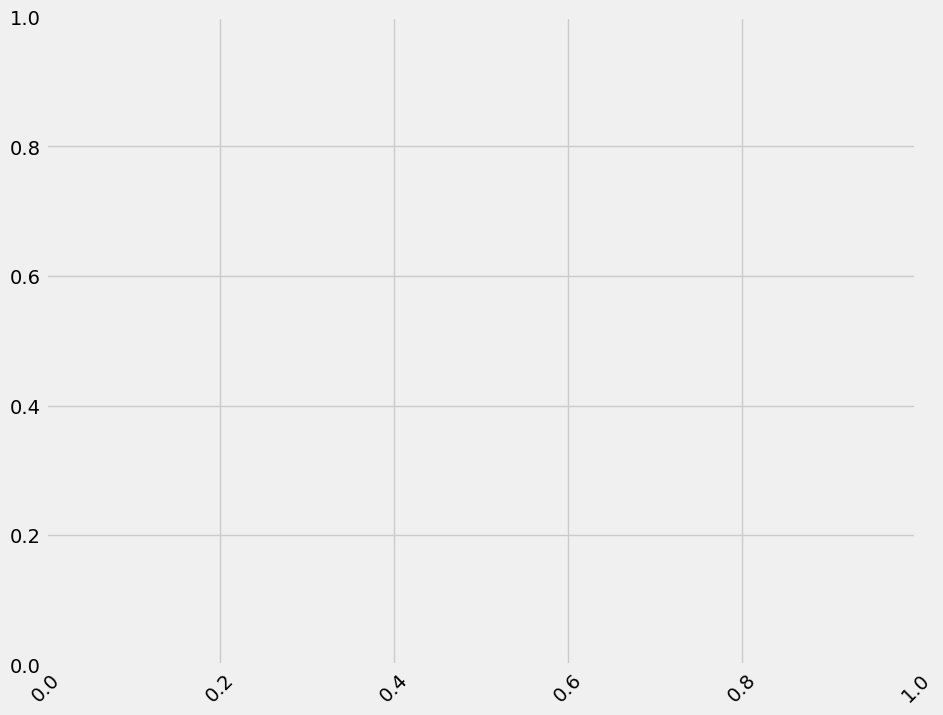

In [10]:
plots.figure( figsize = (10,8) )
plots.xticks(rotation=45)
boxes(sf, 'Total Compensation', 'Organization Group')

## <span style="color:blue;font-weight:bold;font-size:1.1em">2. Standard Deviation</span>

The standard deviation:
1. Measures the spread of data points **around** the mean, and
2. Provides a measure of **distance** unique to the data set.

In the case of outliers, how do we determine if one value is **far away** from the other values in a data set?

### <span style="color:blue;font-weight:bold;font-size:1.1em"><span style="color:red">Sample</span> Standard Deviation </span>

The sample standard deviation is usually denoted with one of these $S_x$, $s_x$ or just $S$.

$$s = \sqrt{\frac{1}{n-1}\sum_{i=1}^n(\,x_i - \overline{x}\,)^2}$$

The command **np.std** computes the <span style="color:red;font-weight:bold">population standard deviation</span>, not the <span style="color:red;font-weight:bold">sample standard deviation</span>.  

$$\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^n(x_i - \mu)^2}$$

(In this formula the computer assumes $\mu = \overline{x}$.)

For very large samples, they are most likely close enough that we couldn't tell the difference, but for small samples, they are usually noticeably different.  

<span style="color:red;font-weight:bold;font-size:1.25em">Check out this [YouTube video](https://youtu.be/fs4eg1u7oY0?si=Jm-xpgF1oh5Oo27f&t=375) to learn about estimation, sampling, and variaton.</span>

#### <span style="color:blue;font-weight:bold;font-size:1.1em">Example: How to Calculate Standard Deviation</span>

First, let's create a data array.

In [11]:
sd_array = make_array(2,3,3,9)
sd_table = Table().with_columns('Value', make_array(2,3,3,9))
sd_table

Value
2
3
3
9


#### <span style="color:blue;font-weight:bold;font-size:1.1em">Add the Deviations</span>

The deviation is the data point minus the mean.

In [12]:
m = np.average(sd_array)
deviations = sd_array - m
sd_table = sd_table.with_column('Deviation', deviations)
sd_table

Value,Deviation
2,-2.25
3,-1.25
3,-1.25
9,4.75


#### <span style="color:blue;font-weight:bold;font-size:1.1em">Square the Deviations</span>

The squared deviations are positive. This is needed because the deviations always sum to 0.

In [13]:
sd_table = sd_table.with_columns('Squared Deviation', deviations ** 2)
sd_table

Value,Deviation,Squared Deviation
2,-2.25,5.0625
3,-1.25,1.5625
3,-1.25,1.5625
9,4.75,22.5625


#### <span style="color:blue;font-weight:bold;font-size:1.1em">Find the Variance which is the Average Squared Deviation using $\frac{1}{n-1}$</span>

In [14]:
variance = ...
variance

Ellipsis

#### <span style="color:blue;font-weight:bold;font-size:1.1em">Find the Standard Deviation which is the $\sqrt{v}$</span>

In [15]:
s = ...

## <span style="color:blue;font-weight:bold;font-size:1.1em">Histograms, Bins, and Calculations</span>

### <span style="font-weight:bold;font-size:1.1em">Calculations with Histogram Bars</span>

#### The bars of a histogram are rectangles whose area are proprotional to the number of individuals represented. The area formula is used:
$$\begin{align}\textbf{Area} &= \textbf{Length} \times \textbf{Width} \\\textbf{Percent of Total Area}&=\textbf{bin width} \times \textbf{bar height}\end{align}$$

Let's practice using the skyscraper data set.

### <span style="font-size:1.1em">Practice Question: For the skyscraper heights histogram below $(n=200)$, determine how many skyscrapers are between 200 and 250 meters tall.</span>

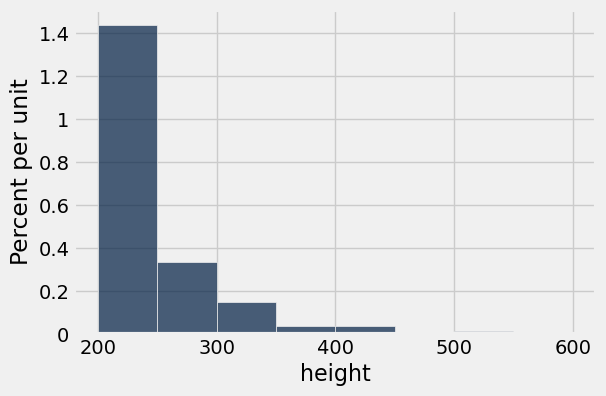

In [16]:
sky.hist('height', bins = np.arange(200,601, 50))

In [19]:
sky_200_250 = ...

### <span style="font-size:1.1em">Practice Question: For the Sleep histogram below $(n=129)$, determine how many students slept between 6 and 7 per night.</span>

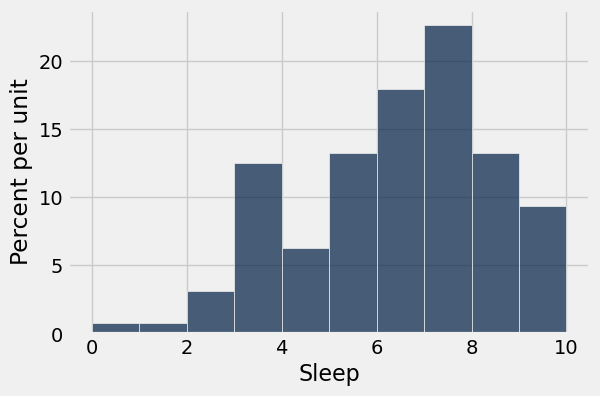

In [17]:
pers.hist("Sleep", bins = np.arange(0,11,1))

In [18]:
num_6to7 = ...

## 3. Line Plots

With time series data, a Python line plot often helps with exploratory data analysis. We will use a census table to demonstrate.

In [381]:
full = Table.read_table('nc-est2014-agesex-res.csv')
full.show(5)

SEX,AGE,CENSUS2010POP,ESTIMATESBASE2010,POPESTIMATE2010,POPESTIMATE2011,POPESTIMATE2012,POPESTIMATE2013,POPESTIMATE2014
0,0,3944153,3944160,3951330,3963071,3926665,3945610,3948350
0,1,3978070,3978090,3957888,3966510,3978006,3943077,3962123
0,2,4096929,4096939,4090862,3971573,3979952,3992690,3957772
0,3,4119040,4119051,4111920,4102501,3983049,3992425,4005190
0,4,4063170,4063186,4077552,4122303,4112638,3994047,4003448


Notice some issues with the data set we can see above and which are shown in the 2 tables below this cell:
1. Three sexes
2. An age of 999
3. Lots of columns (only need a few of them)
4. Long and confusing column titles

In [386]:
full.group('SEX')

SEX,count
0,102
1,102
2,102


In [387]:
full.group('AGE').sort('AGE', True).show(4)

AGE,count
999,3
100,3
99,3
98,3


#### Let's fix all thse issues in the code block below.

In [389]:
partial = full.select('SEX', 'AGE', 'POPESTIMATE2010', 'POPESTIMATE2014')
simple = partial.relabeled(2, '2010').relabeled(3, '2014')
no_999 = simple.where('AGE', are.below(999))
everyone = no_999.where('SEX', 0).drop('SEX')
everyone.show(7)

AGE,2010,2014
0,3951330,3948350
1,3957888,3962123
2,4090862,3957772
3,4111920,4005190
4,4077552,4003448
5,4064653,4004858
6,4073013,4134352


### <span style="color:blue;font-weight:bold;font-size:1.1em">Constructing the Line Plot</span>

#### <span style="font-weight:bold;font-size:1.1em">The first command adds a title to the graphic.</span>

The title trick works for most of the graphics commands we use in the course.

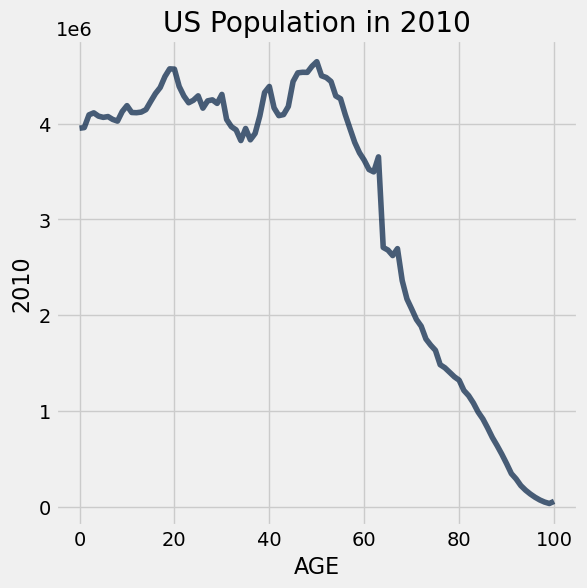

In [390]:
everyone.plot('AGE', '2010')
plots.title('US Population in 2010'); 

### <span style = font-weight:bold;color:blue;font-size:1.1em>Specifying no $y$-variable column tells Python to create a line plot for EVERY column</span>

#### Age distribution for two different years

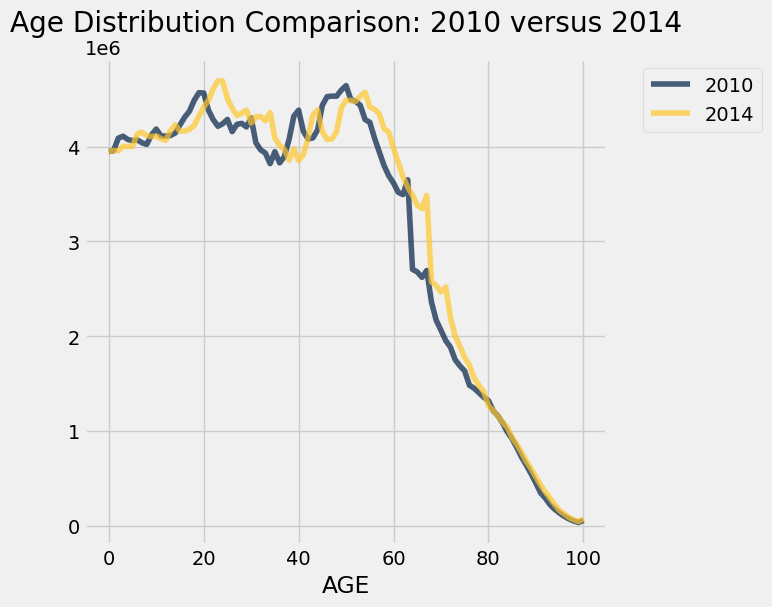

In [394]:
everyone.plot('AGE')
plots.title('Age Distribution Comparison: 2010 versus 2014') ;

### <span style = font-weight:bold;color:blue;font-size:1.1em>Males and Females in 2014</span>

In [396]:
males = no_999.where('SEX', 1).drop('SEX')
females = no_999.where('SEX', 2).drop('SEX')
pop_2014 = Table().with_columns(
    'Age', males.column('AGE'),
    'Males', males.column('2014'),
    'Females', females.column('2014')
)
pop_2014.show(5)

Age,Males,Females
0,2017857,1930493
1,2023253,1938870
2,2022502,1935270
3,2048618,1956572
4,2043498,1959950


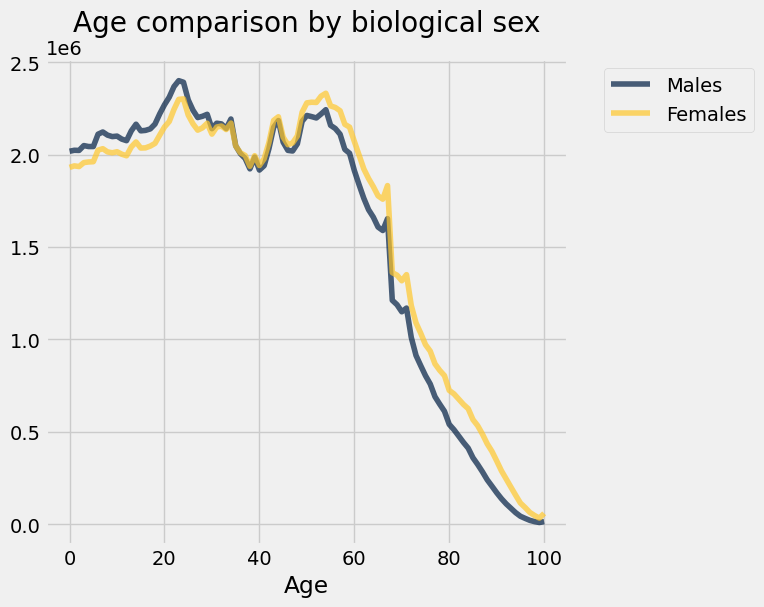

In [404]:
pop_2014.plot('Age')
plots.title('Age comparison by biological sex') ;

### <span style = font-weight:bold;color:blue;font-size:1.1em>Percent Comparison of Males and Females in 2014</span>

In [407]:
total = pop_2014.column('Males') + pop_2014.column('Females')
pct_female = pop_2014.column('Females') / total * 100
pct_female = np.round(pct_female, 3)
pop_2014 = pop_2014.with_column('Percent female', pct_female)
pop_2014.show(7)

Age,Males,Females,Percent female
0,2017857,1930493,48.894
1,2023253,1938870,48.935
2,2022502,1935270,48.898
3,2048618,1956572,48.851
4,2043498,1959950,48.957
5,2043467,1961391,48.975
6,2110328,2024024,48.956


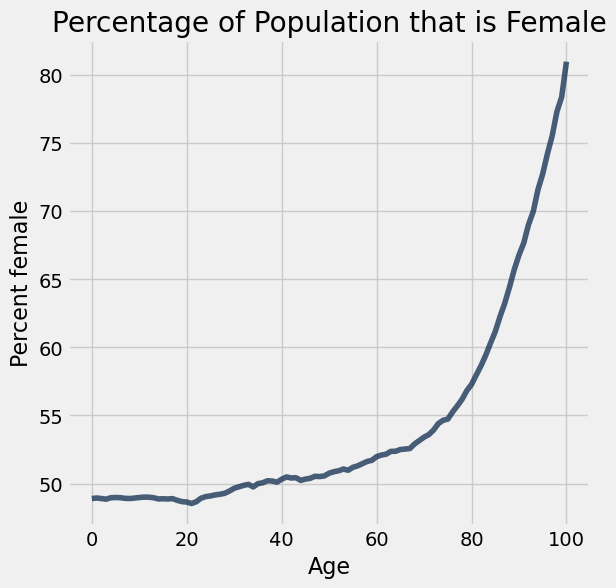

In [408]:
pop_2014.plot('Age', 'Percent female')
plots.title('Percentage of Population that is Female');

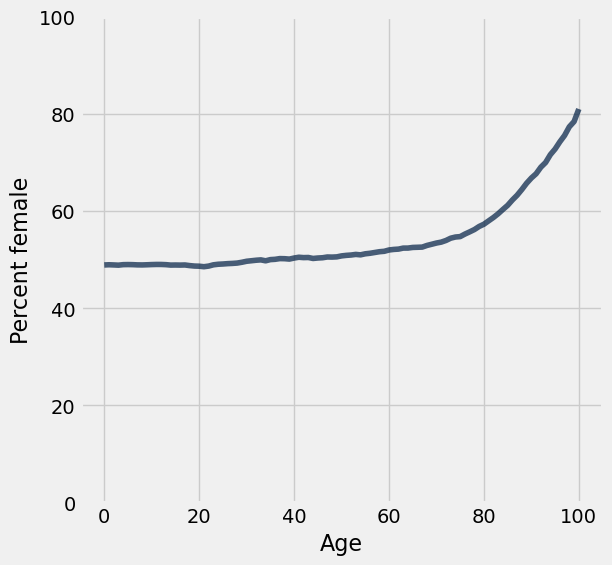

In [409]:
# ^^ Look at the y-axis! Trend is not as dramatic as you might think
pop_2014.plot('Age', 'Percent female')
plots.ylim(0, 100); 

In [410]:
total = pop_2014.column('Males') + pop_2014.column('Females')
pct_male = pop_2014.column('Males') / total * 100
pop_2014 = pop_2014.with_column('Percent male', pct_male)
pop_2014.show(7)

Age,Males,Females,Percent female,Percent male
0,2017857,1930493,48.894,51.1063
1,2023253,1938870,48.935,51.0649
2,2022502,1935270,48.898,51.102
3,2048618,1956572,48.851,51.1491
4,2043498,1959950,48.957,51.0435
5,2043467,1961391,48.975,51.0247
6,2110328,2024024,48.956,51.0437


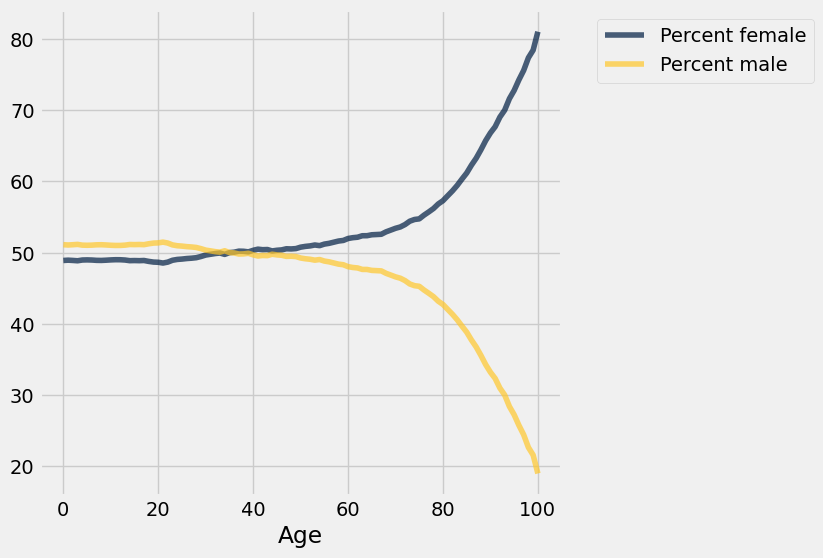

In [411]:
pop_2014.drop(1, 2).plot("Age")

### <span style="color:blue;font-weight:bold;font-size:1.1em">Two more examples using line plots.</span>

Here's some data involving a something related to the Ideal Gas Laws known as [Boyles' Law](https://www.sas.upenn.edu/~kimg/mcephome/chem501/data/boyles.html).  

The Ideal Gas Law is $$\displaystyle PV = nRT$$where $n$ is the amount of the gas, $P$, $V$ and $T$ stand for pressure, volume and temperature, and $R$ is the so-called *Ideal Gas Constant*. Boyles' Law is $$P_1V_1 = P_2V_2$$ This means that if an amount of gas is kept at a constant temperature while the pressure is changed the volume will change according to this formula.  

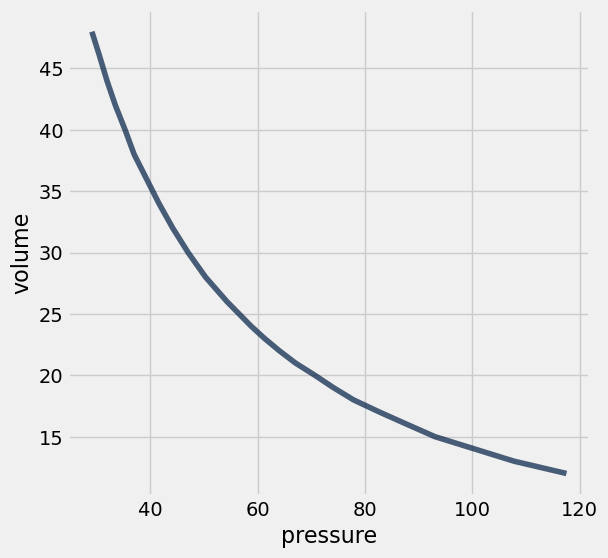

In [413]:
boyles = Table.read_table("boyleslawdata.csv")
boyles.plot("pressure")

My friend is a real whiz at chemistry and she tells me that if we plot $\frac{1}{P}$ against volume instead, we should get a line.  Let's see if she's tell me the truth.

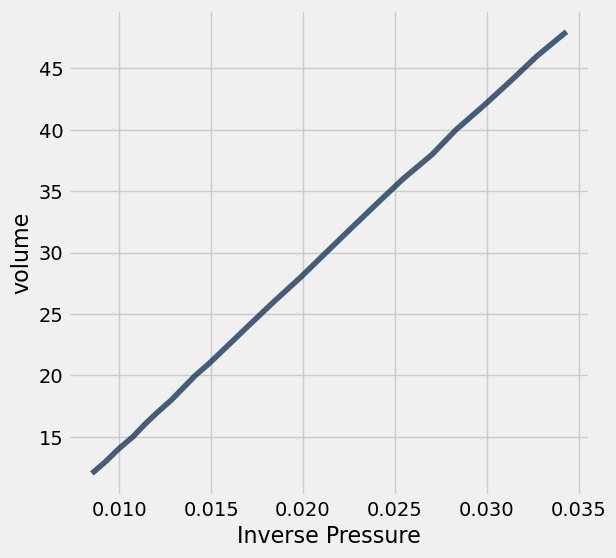

In [414]:
boyles = boyles.with_column("Inverse Pressure", boyles.column("pressure")**(-1))

boyles.plot("Inverse Pressure", "volume")

## When are line plots not appropriate? ##

We will discuss situations where another type of graph is appropriate.

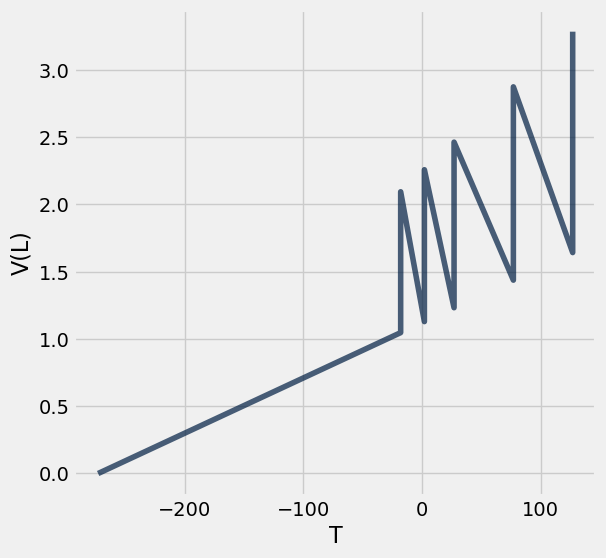

In [415]:
charles = Table.read_table("charleslawdata.csv").drop("Unnamed: 2")

charles.plot("T")

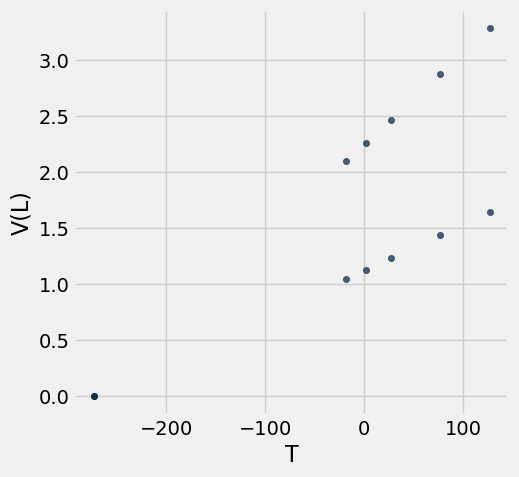

In [416]:
charles.scatter("T")

In [417]:
# Highest grossing movies as of 2017
top_movies = Table.read_table('top_movies_2017.csv')
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


In [418]:
top10_adjusted = top_movies.take(np.arange(10))
top10_adjusted

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


In [419]:
# Convert to millions of dollars for readability
millions = np.round(top10_adjusted.column('Gross (Adjusted)') / 1000000, 3)
top10_adjusted = top10_adjusted.with_column('Millions', millions)
top10_adjusted

Title,Studio,Gross,Gross (Adjusted),Year,Millions
Gone with the Wind,MGM,198676459,1796176700,1939,1796.18
Star Wars,Fox,460998007,1583483200,1977,1583.48
The Sound of Music,Fox,158671368,1266072700,1965,1266.07
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982,1261.09
Titanic,Paramount,658672302,1204368000,1997,1204.37
The Ten Commandments,Paramount,65500000,1164590000,1956,1164.59
Jaws,Universal,260000000,1138620700,1975,1138.62
Doctor Zhivago,MGM,111721910,1103564200,1965,1103.56
The Exorcist,Warner Brothers,232906145,983226600,1973,983.227
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937,969.01


A line plot doesn't make sense here: don't do this!

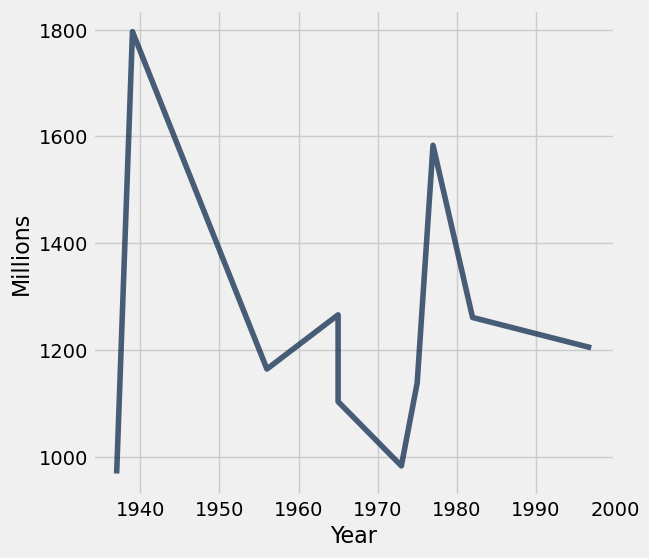

In [420]:
top10_adjusted.plot('Year', 'Millions')

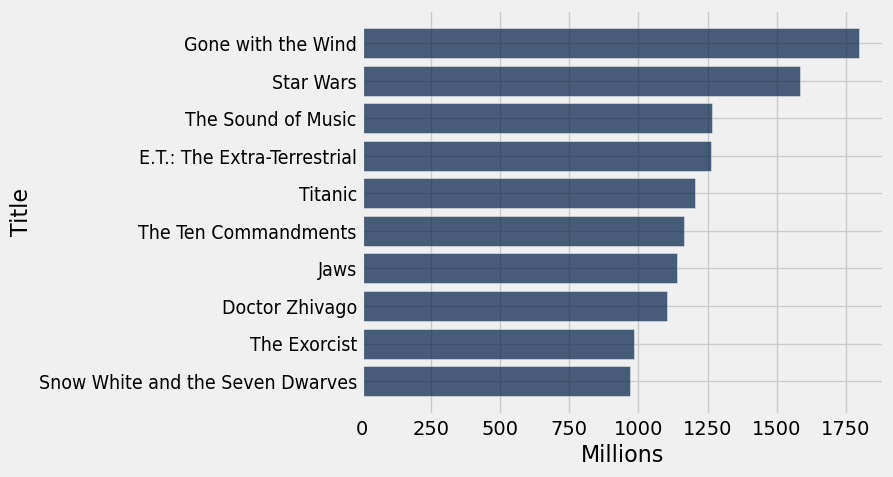

In [421]:
top10_adjusted.barh('Title', 'Millions')

In [422]:
# Actors and their highest grossing movies
actors = Table.read_table('actors.csv')
actors.column('Actor')

array(['Harrison Ford', 'Samuel L. Jackson', 'Morgan Freeman', 'Tom Hanks',
       'Robert Downey, Jr.', 'Eddie Murphy', 'Tom Cruise', 'Johnny Depp',
       'Michael Caine', 'Scarlett Johansson', 'Gary Oldman',
       'Robin Williams', 'Bruce Willis', 'Stellan Skarsgard',
       'Anthony Daniels', 'Ian McKellen', 'Will Smith', 'Stanley Tucci',
       'Matt Damon', 'Robert DeNiro', 'Cameron Diaz', 'Liam Neeson',
       'Andy Serkis', 'Don Cheadle', 'Ben Stiller', 'Helena Bonham Carter',
       'Orlando Bloom', 'Woody Harrelson', 'Cate Blanchett',
       'Julia Roberts', 'Elizabeth Banks', 'Ralph Fiennes', 'Emma Watson',
       'Tommy Lee Jones', 'Brad Pitt', 'Adam Sandler', 'Daniel Radcliffe',
       'Jonah Hill', 'Owen Wilson', 'Idris Elba', 'Bradley Cooper',
       'Mark Wahlberg', 'Jim Carrey', 'Dustin Hoffman',
       'Leonardo DiCaprio', 'Jeremy Renner', 'Philip Seymour Hoffman',
       'Sandra Bullock', 'Chris Evans', 'Anne Hathaway'],
      dtype='<U22')

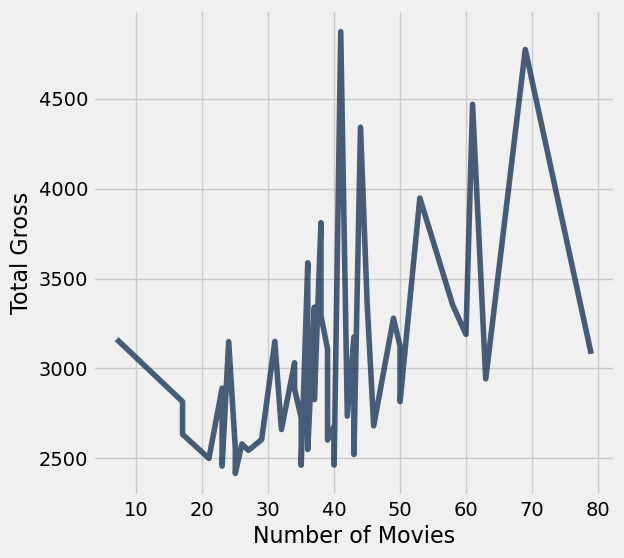

In [423]:
actors.plot('Number of Movies', 'Total Gross')

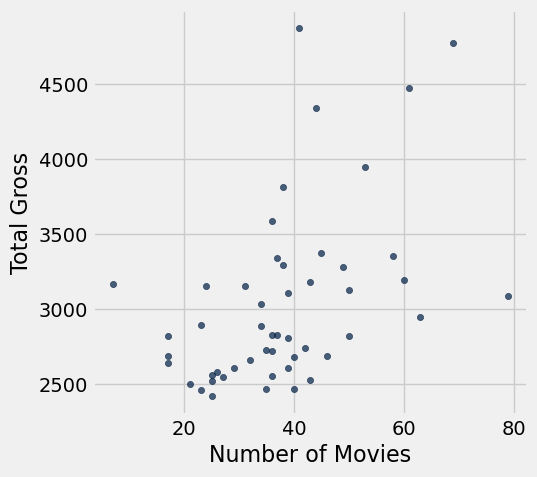

In [424]:
actors.scatter('Number of Movies', 'Total Gross')

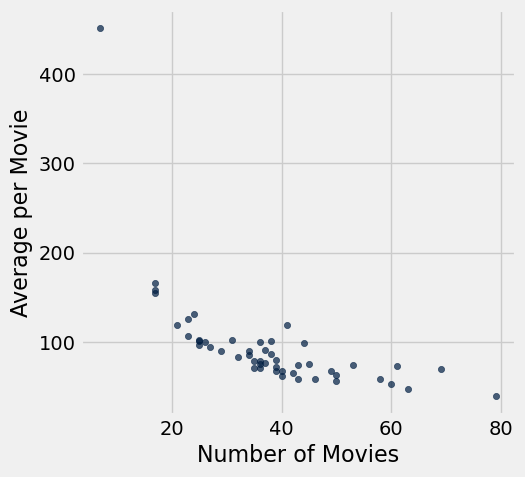

In [425]:
actors.scatter('Number of Movies', 'Average per Movie')

In [20]:
outlier_actor_is = ...

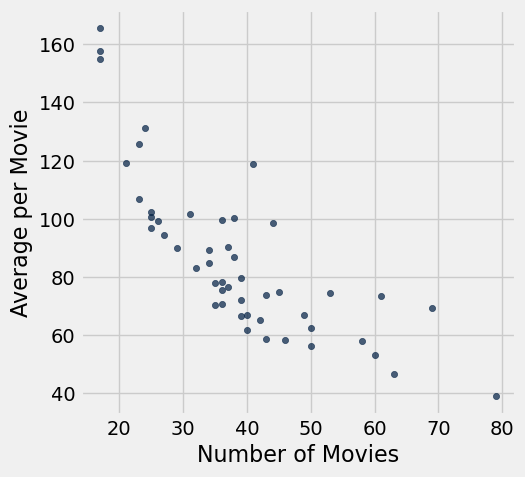

In [427]:
actors.where('Average per Movie', are.below(400)).scatter('Number of Movies', 'Average per Movie')